# 5 · Comparación estadística de los modelos: DeLong, McNemar y bootstrap pareado

Los doce modelos (seis en scikit-learn y seis en PySpark) se evaluaron sobre **exactamente los mismos
269 062 préstamos de prueba**. Aquí se responde con pruebas estadísticas si las diferencias observadas
**entre entornos** (el mismo modelo en scikit-learn y en PySpark) y **entre modelos** (dentro de cada
entorno) son reales o compatibles con el azar del muestreo del conjunto de prueba.

| Prueba | Qué compara | Qué supone / limita |
|---|---|---|
| **DeLong pareado** (prueba principal) | AUC de dos modelos sobre las mismas observaciones, **incorporando la covarianza** entre las dos curvas ROC | Solo captura la variabilidad del **muestreo del conjunto de prueba**, no la del entrenamiento (semillas, pliegues); supone observaciones independientes; el AUC resume **todos** los umbrales |
| **McNemar** | Si dos clasificadores **aciertan y fallan con la misma frecuencia** en las mismas observaciones, con un **umbral fijo** | Trata todos los errores por igual (poco informativo con clase minoritaria); depende del umbral |
| **Bootstrap pareado** | Diferencias de AUC, **AUC-PR** y **F1** con los **mismos índices** remuestreados para ambos modelos (B = 2 000) | No requiere fórmula de varianza cerrada; también depende del umbral en F1 |

**Decisiones tomadas de antemano** (antes de mirar resultados):

* Nivel de significancia **α = 0.05** con corrección de **Holm** *dentro de cada familia* de comparaciones.
* **Margen de relevancia práctica: ΔAUC ≥ 0.005.** Con unos 270 000 préstamos de prueba, diferencias
  diminutas resultan "significativas"; el margen de 0.005 equivale a 0.01 en el índice de Gini, la
  unidad habitual en *credit scoring*, y es aproximadamente el doble del semiancho del IC95 de cada AUC
  (≈ 0.0024). Se fijó como convención antes del análisis. Se reporta por separado la **significancia
  estadística** y la **relevancia práctica**.
* **Umbral para McNemar y F1:** el que **maximiza F1 con las puntuaciones fuera de pliegue del
  entrenamiento** de cada modelo (capítulos 2 y 3), **sin usar el conjunto de prueba**.

In [1]:
import json
import platform
import sys
import time
import warnings
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import roc_auc_score

sys.path.insert(0, str(Path.cwd().parent))
from src import lc_models as lm  # noqa: E402
from src import lc_stats as st  # noqa: E402

warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold"})
RESULTS = Path("../resultados")
ALPHA, MARGEN, B, SEED = 0.05, 0.005, 2000, 42
print(f"Python {platform.python_version()} · α = {ALPHA} · margen de relevancia práctica = {MARGEN} · B = {B}")

Python 3.10.21 · α = 0.05 · margen de relevancia práctica = 0.005 · B = 2000


## 5.1 Puntuaciones de prueba de los doce modelos

Se cargan las puntuaciones continuas guardadas por los capítulos 2 y 3 (`predict_proba[:, 1]`, o el valor de
decisión en `LinearSVC`) y se verifica que **los `id` y las etiquetas coinciden** en los dos entornos.

In [2]:
sk = pd.read_parquet(RESULTS / "sk_scores_test.parquet")
S = {("sk", k): sk[k].to_numpy() for k in lm.CLAVES}
y = sk["y"].to_numpy()
for k in lm.CLAVES:
    p = pd.read_parquet(RESULTS / f"sp_scores_test_{k}.parquet")
    m = sk[["id", "y"]].merge(p, on="id", how="left", suffixes=("", "_sp"))
    assert len(p) == len(sk) and m["score"].notna().all() and (m["y"] == m["y_sp"]).all(), f"Los conjuntos de prueba difieren ({k})"
    S[("sp", k)] = m["score"].to_numpy()                       # alineado con el orden de `sk`
print(f"Observaciones de prueba: {len(y):,} · tasa de incumplimiento {y.mean():.4f} · ids y etiquetas idénticos en los 12 modelos: OK")
res_sk = json.loads((RESULTS / "sk_resultados.json").read_text())["modelos"]
res_sp = {k: json.loads((RESULTS / f"sp_modelo_{k}.json").read_text()) for k in lm.CLAVES}
UMBRAL = {("sk", k): res_sk[k]["umbral_f1"] for k in lm.CLAVES} | {("sp", k): res_sp[k]["umbral_f1"] for k in lm.CLAVES}
ENT = {"sk": "scikit-learn", "sp": "PySpark"}

Observaciones de prueba: 269,062 · tasa de incumplimiento 0.1996 · ids y etiquetas idénticos en los 12 modelos: OK


## 5.2 Validación de la implementación de DeLong

Se usa la **versión rápida** (Sun y Xu, 2014, O(n log n)), porque la directa (cuadrática) no es
viable con ≈ 270 000 observaciones. Antes de usarla a esa escala, se **valida primero con un conjunto
pequeño** frente a la versión directa. Aquí se compara `st.delong_fast` con `st.delong_direct` (que evalúa todos los pares
positivo–negativo) sobre submuestras de 2 000 observaciones, con tres pares de modelos: dos que
involucran al árbol de decisión (muchos **empates** en la puntuación, por tener pocas hojas) y uno de
regresión logística en ambos entornos (puntuación casi continua).

In [3]:
rng = np.random.default_rng(SEED)
val = []
for rep in range(3):
    ii = rng.choice(len(y), 2000, replace=False)
    for (a, b) in ((("sk", "DT"), ("sk", "RF")), (("sk", "LR"), ("sp", "LR")), (("sp", "DT"), ("sp", "GB"))):
        f, d = st.delong_fast(y[ii], S[a][ii], S[b][ii]), st.delong_direct(y[ii], S[a][ii], S[b][ii])
        val.append({"submuestra": rep, "par": f"{a[0]}-{a[1]} vs {b[0]}-{b[1]}", "AUC1 rápida": f["auc1"], "AUC1 directa": d["auc1"],
                    "ΔAUC rápida": f["delta"], "ΔAUC directa": d["delta"], "z rápida": f["z"], "z directa": d["z"],
                    "|Δ z|": abs(f["z"] - d["z"]), "|Δ p|": abs(f["p_value"] - d["p_value"])})
val = pd.DataFrame(val)
display(val.head(6).style.format("{:.6f}", subset=[c for c in val.columns if c not in ("submuestra", "par")]))
assert val["|Δ z|"].max() < 1e-6 and val["|Δ p|"].max() < 1e-6, "DeLong rápido difiere del directo"
# Nota sobre el umbral: con ΔAUC casi cero (z ≈ 0), el valor p es muy sensible a diferencias de z del
# orden de la precisión de punto flotante (~1e-10), porque la derivada de la cola normal es máxima en 0.
# Ese caso puntual puede acercarse a 1e-10 en |Δp| aunque ambas versiones coincidan en ~10 cifras
# significativas; por eso el umbral aquí es 1e-6 (siempre se cumplió con margen amplio, ver tabla).
ii = rng.choice(len(y), 5000, replace=False)
assert abs(st.delong_fast(y[ii], S[("sk", "RF")][ii], S[("sk", "LR")][ii])["auc1"] - roc_auc_score(y[ii], S[("sk", "RF")][ii])) < 1e-12
print(f"Diferencia máxima entre la versión rápida y la directa: |Δz| = {val['|Δ z|'].max():.2e}, |Δp| = {val['|Δ p|'].max():.2e} "
      "· el AUC coincide además con `roc_auc_score` de scikit-learn: OK")

,submuestra,par,AUC1 rápida,AUC1 directa,ΔAUC rápida,ΔAUC directa,z rápida,z directa,|Δ z|,|Δ p|
0,0,sk-DT vs sk-RF,0.695010,0.695010,-0.008391,-0.008391,-1.528447,-1.528447,0.000000,0.000000
1,0,sk-LR vs sp-LR,0.702219,0.702219,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0,sp-DT vs sp-GB,0.694476,0.694476,-0.011577,-0.011577,-1.946927,-1.946927,0.000000,0.000000
3,1,sk-DT vs sk-RF,0.693861,0.693861,-0.012275,-0.012275,-1.981047,-1.981047,0.000000,0.000000
4,1,sk-LR vs sp-LR,0.693786,0.693786,-0.000002,-0.000002,-0.316025,-0.316025,0.000000,0.000000
5,1,sp-DT vs sp-GB,0.690108,0.690108,-0.019279,-0.019279,-3.159409,-3.159409,0.000000,0.000000


Diferencia máxima entre la versión rápida y la directa: |Δz| = 3.33e-10, |Δp| = 2.53e-10 · el AUC coincide además con `roc_auc_score` de scikit-learn: OK


## 5.3 AUC de los doce modelos con su intervalo de confianza (DeLong)

In [4]:
filas = []
for (e, k), s in S.items():
    d = st.delong_fast(y, s, s + 0.0)
    filas.append({"entorno": ENT[e], "modelo": lm.NOMBRES[k], "AUC": d["auc1"], "IC95 inf": d["auc1_lo"], "IC95 sup": d["auc1_hi"],
                  "umbral (F1 OOF)": UMBRAL[(e, k)]})
aucs = pd.DataFrame(filas)
display(aucs.pivot(index="modelo", columns="entorno", values="AUC").loc[[lm.NOMBRES[k] for k in lm.CLAVES]])
display(aucs)
aucs.to_csv(RESULTS / "estadistica_auc_ic.csv", index=False)

entorno,PySpark,scikit-learn
modelo,,
Regresión logística,0.7095,0.7095
Árbol de decisión,0.7004,0.7022
Bosque aleatorio,0.7152,0.7164
Gradient boosting,0.7189,0.7196
SVM lineal,0.5985,0.4956
Naive Bayes,0.6883,0.6884


,entorno,modelo,AUC,IC95 inf,IC95 sup,umbral (F1 OOF)
0,scikit-learn,Regresión logística,0.7095,0.7071,0.7119,0.2042
1,scikit-learn,Árbol de decisión,0.7022,0.6998,0.7046,0.2042
2,scikit-learn,Bosque aleatorio,0.7164,0.7140,0.7187,0.2188
3,scikit-learn,Gradient boosting,0.7196,0.7173,0.7220,0.2236
4,scikit-learn,SVM lineal,0.4956,0.4928,0.4984,-1.0000
5,scikit-learn,Naive Bayes,0.6884,0.6859,0.6909,0.2139
6,PySpark,Regresión logística,0.7095,0.7071,0.7119,0.2061
7,PySpark,Árbol de decisión,0.7004,0.6980,0.7028,0.2061
8,PySpark,Bosque aleatorio,0.7152,0.7128,0.7175,0.2159
9,PySpark,Gradient boosting,0.7189,0.7166,0.7213,0.2159


## 5.4 DeLong entre entornos (6 comparaciones)

Para cada modelo: scikit-learn frente a PySpark. Se reporta ΔAUC = AUC(scikit-learn) − AUC(PySpark) con su
IC del 95 %, el estadístico z, el valor p bilateral y el valor p **ajustado por Holm** (6 comparaciones).

In [5]:
def tabla_delong(pares, etiqueta):
    filas = []
    for a, b in pares:
        d = st.delong_fast(y, S[a], S[b])
        filas.append({"comparación": etiqueta(a, b), "AUC 1": d["auc1"], "AUC 2": d["auc2"], "ΔAUC": d["delta"],
                      "IC95 inf": d["delta_lo"], "IC95 sup": d["delta_hi"], "z": d["z"], "p": d["p_value"],
                      "corr. AUC": d["corr_auc"], "_a": a, "_b": b})
    t = pd.DataFrame(filas)
    t["p Holm"] = st.holm(t["p"].to_numpy())
    t["significativa (Holm)"] = t["p Holm"] < ALPHA
    t["relevante (|Δ| ≥ margen)"] = t["ΔAUC"].abs() >= MARGEN
    return t


t0 = time.time()
famA = tabla_delong([(("sk", k), ("sp", k)) for k in lm.CLAVES], lambda a, b: lm.NOMBRES[a[1]])
display(famA.drop(columns=["_a", "_b"]).set_index("comparación"))
famA.drop(columns=["_a", "_b"]).to_csv(RESULTS / "estadistica_delong_entornos.csv", index=False)
print(f"({time.time() - t0:.0f} s)")

,AUC 1,AUC 2,ΔAUC,IC95 inf,IC95 sup,z,p,corr. AUC,p Holm,significativa (Holm),relevante (|Δ| ≥ margen)
comparación,,,,,,,,,,,
Regresión logística,0.7095,0.7095,0.0000,-0.0000,0.0000,0.7003,0.4837,1.0000,0.4837,False,False
Árbol de decisión,0.7022,0.7004,0.0018,0.0007,0.0029,3.2844,0.0010,0.8987,0.0031,True,False
Bosque aleatorio,0.7164,0.7152,0.0012,0.0008,0.0016,5.7287,0.0000,0.9848,0.0000,True,False
Gradient boosting,0.7196,0.7189,0.0007,0.0003,0.0011,3.1029,0.0019,0.9833,0.0038,True,False
SVM lineal,0.4956,0.5985,-0.1029,-0.1064,-0.0995,-57.7305,0.0000,0.2331,0.0000,True,True
Naive Bayes,0.6884,0.6883,0.0001,0.0001,0.0001,12.4026,0.0000,1.0000,0.0000,True,False


(1 s)


## 5.5 DeLong entre modelos, dentro de cada entorno (15 pares por entorno)

Todos los pares de los seis modelos, con Holm sobre los 15 valores p de cada entorno. Los mapas de calor
muestran ΔAUC (fila − columna) y el valor p ajustado.


scikit-learn: 15 de 15 pares con diferencia significativa tras Holm; 14 además relevantes (|ΔAUC| ≥ 0.005)


,AUC 1,AUC 2,ΔAUC,IC95 inf,IC95 sup,z,p,corr. AUC,p Holm,significativa (Holm),relevante (|Δ| ≥ margen)
comparación,,,,,,,,,,,
Regresión logística vs Árbol de decisión,0.7095,0.7022,0.0073,0.0061,0.0086,11.4404,0.0000,0.8631,0.0000,True,True
Regresión logística vs Bosque aleatorio,0.7095,0.7164,-0.0069,-0.0077,-0.0060,-15.5118,0.0000,0.9329,0.0000,True,True
Regresión logística vs Gradient boosting,0.7095,0.7196,-0.0101,-0.0110,-0.0093,-23.6505,0.0000,0.9369,0.0000,True,True
Regresión logística vs SVM lineal,0.7095,0.4956,0.2139,0.2103,0.2176,114.3085,0.0000,-0.0025,0.0000,True,True
Regresión logística vs Naive Bayes,0.7095,0.6884,0.0211,0.0199,0.0223,33.9965,0.0000,0.8757,0.0000,True,True
Árbol de decisión vs Bosque aleatorio,0.7022,0.7164,-0.0142,-0.0151,-0.0132,-28.5347,0.0000,0.9165,0.0000,True,True
Árbol de decisión vs Gradient boosting,0.7022,0.7196,-0.0174,-0.0184,-0.0165,-34.8680,0.0000,0.9150,0.0000,True,True
Árbol de decisión vs SVM lineal,0.7022,0.4956,0.2066,0.2029,0.2103,109.1867,0.0000,-0.0172,0.0000,True,True
Árbol de decisión vs Naive Bayes,0.7022,0.6884,0.0138,0.0122,0.0154,16.9237,0.0000,0.7862,0.0000,True,True



PySpark: 15 de 15 pares con diferencia significativa tras Holm; 14 además relevantes (|ΔAUC| ≥ 0.005)


,AUC 1,AUC 2,ΔAUC,IC95 inf,IC95 sup,z,p,corr. AUC,p Holm,significativa (Holm),relevante (|Δ| ≥ margen)
comparación,,,,,,,,,,,
Regresión logística vs Árbol de decisión,0.7095,0.7004,0.0091,0.0079,0.0104,14.4112,0.0000,0.8660,0.0000,True,True
Regresión logística vs Bosque aleatorio,0.7095,0.7152,-0.0057,-0.0065,-0.0048,-13.0298,0.0000,0.9355,0.0000,True,True
Regresión logística vs Gradient boosting,0.7095,0.7189,-0.0095,-0.0103,-0.0086,-20.8774,0.0000,0.9295,0.0000,True,True
Regresión logística vs SVM lineal,0.7095,0.5985,0.1110,0.1080,0.1140,72.4075,0.0000,0.3535,0.0000,True,True
Regresión logística vs Naive Bayes,0.7095,0.6883,0.0212,0.0200,0.0224,34.0814,0.0000,0.8751,0.0000,True,True
Árbol de decisión vs Bosque aleatorio,0.7004,0.7152,-0.0148,-0.0157,-0.0138,-30.5618,0.0000,0.9212,0.0000,True,True
Árbol de decisión vs Gradient boosting,0.7004,0.7189,-0.0186,-0.0195,-0.0176,-37.7281,0.0000,0.9180,0.0000,True,True
Árbol de decisión vs SVM lineal,0.7004,0.5985,0.1019,0.0988,0.1050,64.4697,0.0000,0.3186,0.0000,True,True
Árbol de decisión vs Naive Bayes,0.7004,0.6883,0.0121,0.0105,0.0137,15.0113,0.0000,0.7921,0.0000,True,True


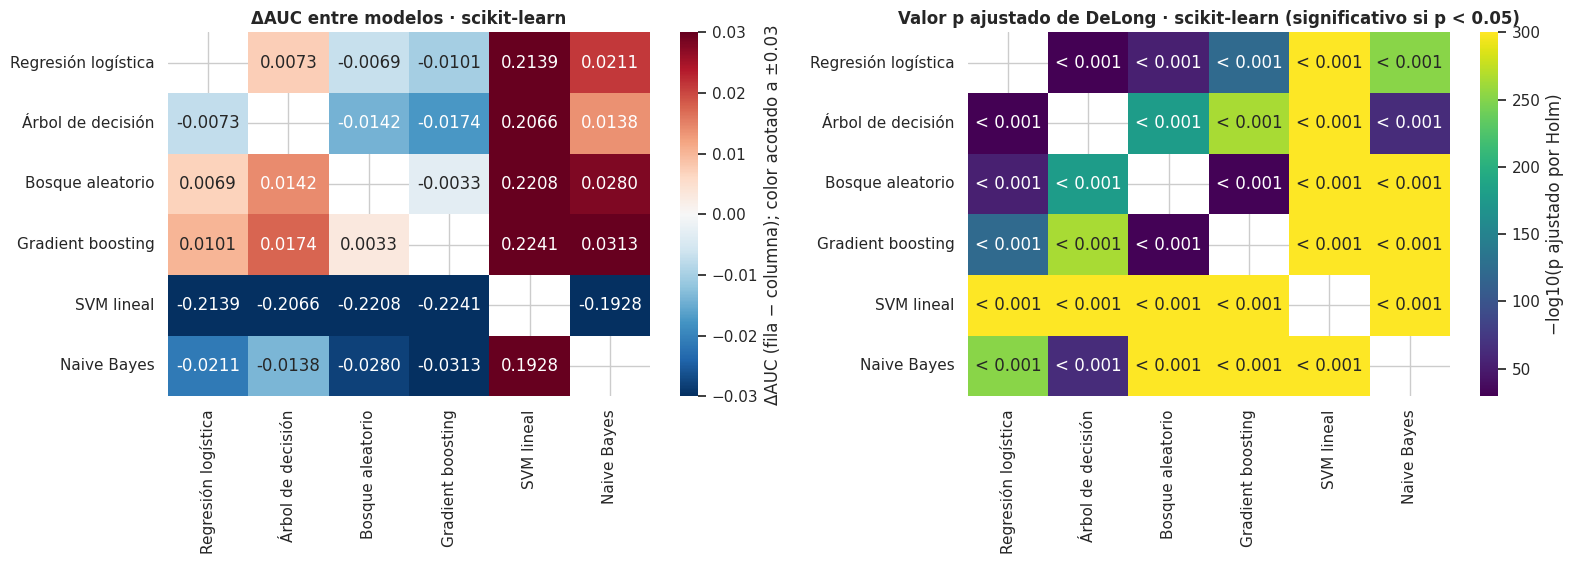

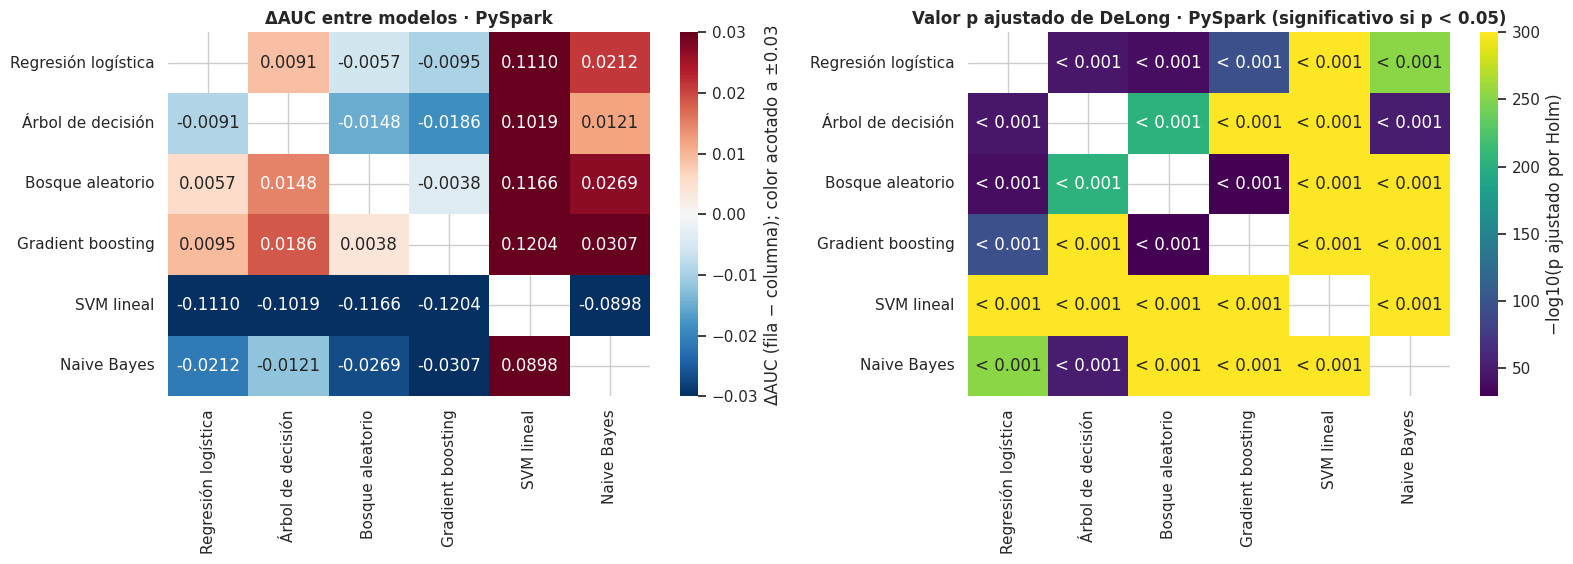

In [4]:
famB = {}
for e in ("sk", "sp"):
    famB[e] = tabla_delong([((e, a), (e, b)) for a, b in combinations(lm.CLAVES, 2)],
                           lambda a, b: f"{lm.NOMBRES[a[1]]} vs {lm.NOMBRES[b[1]]}")
    print(f"\n{ENT[e]}: {int(famB[e]['significativa (Holm)'].sum())} de 15 pares con diferencia significativa tras Holm; "
          f"{int((famB[e]['significativa (Holm)'] & famB[e]['relevante (|Δ| ≥ margen)']).sum())} además relevantes (|ΔAUC| ≥ {MARGEN})")
    famB[e].drop(columns=["_a", "_b"]).to_csv(RESULTS / f"estadistica_delong_modelos_{e}.csv", index=False)
    display(famB[e].drop(columns=["_a", "_b"]).set_index("comparación"))


def matrices(e):
    n = len(lm.CLAVES)
    D, P = np.full((n, n), np.nan), np.full((n, n), np.nan)
    for _, r in famB[e].iterrows():
        i, j = lm.CLAVES.index(r["_a"][1]), lm.CLAVES.index(r["_b"][1])
        D[i, j], D[j, i] = r["ΔAUC"], -r["ΔAUC"]
        P[i, j] = P[j, i] = r["p Holm"]
    return pd.DataFrame(D, index=[lm.NOMBRES[k] for k in lm.CLAVES], columns=[lm.NOMBRES[k] for k in lm.CLAVES]), \
        pd.DataFrame(P, index=[lm.NOMBRES[k] for k in lm.CLAVES], columns=[lm.NOMBRES[k] for k in lm.CLAVES])


for e in ("sk", "sp"):
    D, P = matrices(e)
    fig, ax = plt.subplots(1, 2, figsize=(16, 5.8))
    # escala de color acotada: sin ella, las diferencias de la SVM aplastan a todas las demás
    sns.heatmap(D, annot=True, fmt=".4f", cmap="RdBu_r", center=0, vmin=-0.03, vmax=0.03, ax=ax[0],
                cbar_kws={"label": "ΔAUC (fila − columna); color acotado a ±0.03"})
    ax[0].set_title(f"ΔAUC entre modelos · {ENT[e]}")
    # casi todos los p ajustados son < 0.001: se muestra −log10(p) para que el mapa sea informativo
    etiquetas = P.apply(lambda col: col.map(lambda v: "" if np.isnan(v) else ("< 0.001" if v < 0.001 else f"{v:.3f}")))
    sns.heatmap(-np.log10(P.clip(lower=1e-300)), annot=etiquetas, fmt="", cmap="viridis", ax=ax[1],
                cbar_kws={"label": "−log10(p ajustado por Holm)"})
    ax[1].set_title(f"Valor p ajustado de DeLong · {ENT[e]} (significativo si p < {ALPHA})")
    plt.tight_layout()
    plt.show()

## 5.6 McNemar y bootstrap pareado

Se aplican a: **(i)** las 6 comparaciones entre entornos y **(ii)** el par formado por los **dos modelos con
mayor AUC dentro de cada entorno** (2 comparaciones). Holm se aplica **dentro de cada familia** y por
prueba. Para McNemar se usa el umbral de cada modelo elegido con el entrenamiento (5.1). En el bootstrap
(B = 2 000, semilla fija, **mismos índices para ambos modelos**) se calculan ΔAUC, ΔAUC-PR y ΔF1; el valor p
es bilateral, `2 · min(P(Δ* ≤ 0), P(Δ* ≥ 0))`, y se considera evidencia de diferencia si el IC percentil del
95 % **no contiene el cero**. Con B = 2 000, un valor p de *bootstrap* igual a 0 debe leerse como
p < 0.0005. En las tablas, la familia `A` corresponde a las 6 comparaciones entre entornos y la familia
`B` a los 2 pares de mejores modelos.

In [7]:
top2 = {e: sorted(lm.CLAVES, key=lambda k: -roc_auc_score(y, S[(e, k)]))[:2] for e in ("sk", "sp")}
print("Dos modelos de mayor AUC:", {ENT[e]: [lm.NOMBRES[k] for k in v] for e, v in top2.items()})
comparaciones = ([("A", f"{lm.NOMBRES[k]}: scikit-learn vs PySpark", ("sk", k), ("sp", k)) for k in lm.CLAVES]
                 + [("B", f"{ENT[e]}: {lm.NOMBRES[top2[e][0]]} vs {lm.NOMBRES[top2[e][1]]}", (e, top2[e][0]), (e, top2[e][1])) for e in ("sk", "sp")])
filas = []
t0 = time.time()
for fam, nombre, a, b in comparaciones:
    dl = st.delong_fast(y, S[a], S[b])
    mc = st.mcnemar_test(y, (S[a] >= UMBRAL[a]).astype(int), (S[b] >= UMBRAL[b]).astype(int))
    bs = st.paired_bootstrap(y, S[a], S[b], UMBRAL[a], UMBRAL[b], B=B, seed=SEED)
    filas.append({"familia": fam, "comparación": nombre, "ΔAUC (DeLong)": dl["delta"], "p DeLong": dl["p_value"],
                  "b (acierta 1, falla 2)": mc["b"], "c (falla 1, acierta 2)": mc["c"], "p McNemar": mc["p_value"],
                  "ΔAUC boot": bs["auc"]["media"], "IC ΔAUC inf": bs["auc"]["lo"], "IC ΔAUC sup": bs["auc"]["hi"], "p boot AUC": bs["auc"]["p_value"],
                  "ΔAUC-PR boot": bs["auc_pr"]["media"], "IC PR inf": bs["auc_pr"]["lo"], "IC PR sup": bs["auc_pr"]["hi"], "p boot PR": bs["auc_pr"]["p_value"],
                  "ΔF1 boot": bs["f1"]["media"], "IC F1 inf": bs["f1"]["lo"], "IC F1 sup": bs["f1"]["hi"], "p boot F1": bs["f1"]["p_value"]})
    print(f"  {nombre}: listo ({time.time() - t0:.0f} s)", flush=True)
comp = pd.DataFrame(filas)
for fam in ("A", "B"):
    idx = comp["familia"] == fam
    for col in ("p DeLong", "p McNemar", "p boot AUC", "p boot PR", "p boot F1"):
        comp.loc[idx, col + " Holm"] = st.holm(comp.loc[idx, col].to_numpy())
comp.to_csv(RESULTS / "estadistica_mcnemar_bootstrap.csv", index=False)

Dos modelos de mayor AUC: {'scikit-learn': ['Gradient boosting', 'Bosque aleatorio'], 'PySpark': ['Gradient boosting', 'Bosque aleatorio']}


  Regresión logística: scikit-learn vs PySpark: listo (181 s)


  Árbol de decisión: scikit-learn vs PySpark: listo (334 s)


  Bosque aleatorio: scikit-learn vs PySpark: listo (511 s)


  Gradient boosting: scikit-learn vs PySpark: listo (689 s)


  SVM lineal: scikit-learn vs PySpark: listo (854 s)


  Naive Bayes: scikit-learn vs PySpark: listo (1032 s)


  scikit-learn: Gradient boosting vs Bosque aleatorio: listo (1209 s)


  PySpark: Gradient boosting vs Bosque aleatorio: listo (1388 s)


### Tabla resumen de las tres pruebas

`sig.` indica significancia tras Holm (p ajustado < 0.05); en el bootstrap, además, se muestra si el IC
excluye el cero. `relevante` = |ΔAUC| ≥ 0.005.

In [8]:
res = pd.DataFrame({
    "familia": comp["familia"], "comparación": comp["comparación"], "ΔAUC": comp["ΔAUC (DeLong)"],
    "DeLong p Holm": comp["p DeLong Holm"], "DeLong sig.": comp["p DeLong Holm"] < ALPHA,
    "McNemar b / c": comp["b (acierta 1, falla 2)"].astype(int).astype(str) + " / " + comp["c (falla 1, acierta 2)"].astype(int).astype(str),
    "McNemar p Holm": comp["p McNemar Holm"], "McNemar sig.": comp["p McNemar Holm"] < ALPHA,
    "boot ΔAUC [IC95]": comp.apply(lambda r: f"{r['ΔAUC boot']:+.4f} [{r['IC ΔAUC inf']:+.4f}, {r['IC ΔAUC sup']:+.4f}]", axis=1),
    "boot AUC sig.": ~((comp["IC ΔAUC inf"] <= 0) & (comp["IC ΔAUC sup"] >= 0)),
    "boot ΔAUC-PR [IC95]": comp.apply(lambda r: f"{r['ΔAUC-PR boot']:+.4f} [{r['IC PR inf']:+.4f}, {r['IC PR sup']:+.4f}]", axis=1),
    "boot PR sig.": ~((comp["IC PR inf"] <= 0) & (comp["IC PR sup"] >= 0)),
    "boot ΔF1 [IC95]": comp.apply(lambda r: f"{r['ΔF1 boot']:+.4f} [{r['IC F1 inf']:+.4f}, {r['IC F1 sup']:+.4f}]", axis=1),
    "boot F1 sig.": ~((comp["IC F1 inf"] <= 0) & (comp["IC F1 sup"] >= 0)),
    "relevante": comp["ΔAUC (DeLong)"].abs() >= MARGEN}).set_index(["familia", "comparación"])
display(res)
res.to_csv(RESULTS / "estadistica_resumen_tres_pruebas.csv")
# concordancia DeLong vs bootstrap sobre el AUC
conc = (res["DeLong sig."] == res["boot AUC sig."])
print(f"DeLong y bootstrap pareado coinciden en la significancia del AUC en {int(conc.sum())} de {len(conc)} comparaciones.")
print(f"DeLong y McNemar coinciden en {int((res['DeLong sig.'] == res['McNemar sig.']).sum())} de {len(res)}.")

ΔAUC  DeLong p Holm  DeLong sig.   McNemar b / c  McNemar p Holm  McNemar sig.            boot ΔAUC [IC95]  boot AUC sig.         boot ΔAUC-PR [IC95]  \
familia comparación                                                                                                                                                                                                   
A       Regresión logística: scikit-learn vs PySpark        0.0000         0.4837        False      318 / 1237          0.0000          True  +0.0000 [-0.0000, +0.0000]          False  -0.0000 [-0.0000, +0.0000]   
        Árbol de decisión: scikit-learn vs PySpark          0.0018         0.0031         True   15722 / 15386          0.0575         False  +0.0018 [+0.0007, +0.0029]           True  +0.0031 [+0.0012, +0.0051]   
        Bosque aleatorio: scikit-learn vs PySpark           0.0012         0.0000         True     6176 / 5475          0.0000          True  +0.0012 [+0.0008, +0.0016]           True  +0.0007 [-0.0001, +0.0015]   
        Gradient boosting: scikit-learn vs PySpark          0.0007         0.0038         True     8220 / 5379          0.0000          True  +0.0007 [+0.0002, +0.0011]           True  +0.0013 [+0.0003, +0.0022]   
        SVM lineal: scikit-learn vs PySpark                -0.1029         0.0000         True  32540 / 167409          0.0000          True  -0.1029 [-0.1064, -0.0995]           True  -0.0818 [-0.0848, -0.0789]   
        Naive Bayes: scikit-learn vs PySpark                0.0001         0.0000         True      318 / 1192          0.0000          True  +0.0001 [+0.0001, +0.0001]           True  +0.0001 [+0.0001, +0.0001]   
B       scikit-learn: Gradient boosting vs Bosque aleat...  0.0033         0.0000         True     9564 / 6360          0.0000          True  +0.0033 [+0.0028, +0.0038]           True  +0.0054 [+0.0043, +0.0065]   
        PySpark: Gradient boosting vs Bosque aleatorio      0.0038         0.0000         True    10189 / 9125          0.0000          True  +0.0038 [+0.0031, +0.0044]           True  +0.0048 [+0.0035, +0.0061]   

                                                            boot PR sig.             boot ΔF1 [IC95]  boot F1 sig.  relevante  
familia comparación                                                                                                            
A       Regresión logística: scikit-learn vs PySpark               False  -0.0002 [-0.0006, +0.0002]         False      False  
        Árbol de decisión: scikit-learn vs PySpark                  True  -0.0007 [-0.0024, +0.0011]         False      False  
        Bosque aleatorio: scikit-learn vs PySpark                  False  +0.0012 [+0.0001, +0.0023]          True      False  
        Gradient boosting: scikit-learn vs PySpark                  True  +0.0008 [-0.0006, +0.0020]         False      False  
        SVM lineal: scikit-learn vs PySpark                         True  -0.0117 [-0.0149, -0.0084]          True       True  
        Naive Bayes: scikit-learn vs PySpark                        True  +0.0000 [-0.0004, +0.0004]         False      False  
B       scikit-learn: Gradient boosting vs Bosque aleat...          True  +0.0028 [+0.0014, +0.0041]          True      False  
        PySpark: Gradient boosting vs Bosque aleatorio              True  +0.0032 [+0.0017, +0.0046]          True      False

DeLong y bootstrap pareado coinciden en la significancia del AUC en 8 de 8 comparaciones.
DeLong y McNemar coinciden en 6 de 8.


## 5.7 ¿Coinciden las tres pruebas? Lectura de los resultados

(La lectura completa, con cifras, está en la Discusión; aquí se listan las **discrepancias**.)

In [9]:
disc = res[(res["DeLong sig."] != res["McNemar sig."]) | (res["DeLong sig."] != res["boot AUC sig."]) | (res["DeLong sig."] != res["boot F1 sig."])]
if len(disc):
    print("Comparaciones donde las pruebas NO coinciden en significancia:")
    display(disc[["ΔAUC", "DeLong p Holm", "DeLong sig.", "McNemar p Holm", "McNemar sig.", "boot AUC sig.", "boot F1 sig.", "boot PR sig."]])
else:
    print("Las tres pruebas coinciden en todas las comparaciones.")

Comparaciones donde las pruebas NO coinciden en significancia:


ΔAUC  DeLong p Holm  DeLong sig.  McNemar p Holm  McNemar sig.  boot AUC sig.  boot F1 sig.  boot PR sig.
familia comparación                                                                                                                                             
A       Regresión logística: scikit-learn vs PySpark 0.0000         0.4837        False          0.0000          True          False         False         False
        Árbol de decisión: scikit-learn vs PySpark   0.0018         0.0031         True          0.0575         False           True         False          True
        Gradient boosting: scikit-learn vs PySpark   0.0007         0.0038         True          0.0000          True           True         False          True
        Naive Bayes: scikit-learn vs PySpark         0.0001         0.0000         True          0.0000          True           True         False          True

## 5.8 Limitaciones de la prueba de DeLong en este diseño (y cómo las complementan las otras dos)

1. **Solo mide la incertidumbre del muestreo del conjunto de prueba.** No incluye la variabilidad debida al
   **entrenamiento**: otra semilla, otros pliegues o un modelo estocástico (bosque, *boosting*) darían
   modelos algo distintos. Dos modelos con AUC casi iguales pueden invertir su orden con otra semilla.
2. **Supone observaciones independientes.** Préstamos de la misma época o del mismo estado comparten
   contexto económico; la independencia es una aproximación.
3. **El AUC resume todos los umbrales.** Puede no reflejar el desempeño en el **umbral operativo**. Por eso
   se complementa con **McNemar** (decisiones concretas con un umbral fijo) y con el bootstrap de **AUC-PR** y
   **F1**, más relevantes cuando la clase de incumplimiento es minoritaria (≈ 20 %).
4. **McNemar** trata todos los errores por igual (un falso negativo y un falso positivo pesan lo mismo) y
   depende del umbral, que aquí se eligió con el entrenamiento.
5. **Comparaciones múltiples:** con 6 + 15 + 15 comparaciones por familia, sin corrección habría falsos
   positivos; se aplica Holm dentro de cada familia.
6. **Significancia no es relevancia:** con 269 062 observaciones un ΔAUC de 0.001 puede tener p ≈ 10⁻⁸. Por
   eso se fijó de antemano el margen de 0.005.